In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
  """Abstract base class for a search problem."""

  @abstractmethod
  def initial_state(self) -> Any:
      """Return the start state."""
      pass

  @abstractmethod
  def is_goal(self, state: Any) -> bool:
      """Return True if state is a goal state."""
      pass

  @abstractmethod
  def actions(self, state: Any) -> List[Any]:
      """Return the legal actions available in the given state."""
      pass

  @abstractmethod
  def result(self, state: Any, action: Any) -> Any:
      """Return the next state after applying action in state."""
      pass

  @abstractmethod
  def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
      """Return the cost of applying action in state to reach next_state."""
      pass

In [3]:
@dataclass
class Node:
  state: Any
  parent: Optional["Node"] = None
  action: Optional[Any] = None
  path_cost: float = 0
  depth: int = 0

  def __post_init__(self):
    if self.parent is not None:
      self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
  algorithm: str
  status: str
  solution: Optional[Node]
  nodes_expanded: int
  max_frontier_size: int
  reached_count: int = 0
  limit: Optional[int] = None
  iterations: Optional[List[Dict[str, Any]]] = None

  @property
  def path(self) -> Optional[List[Any]]:
    if self.solution is None:
      return None
    return reconstruct_path(self.solution)

  @property
  def solution_depth(self) -> Optional[int]:
    if self.solution is None:
      return None
    return self.solution.depth

  @property
  def solution_cost(self) -> Optional[float]:
    if self.solution is None:
      return None
    return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
  "UP": (-1, 0),
  "DOWN": (1, 0),
  "LEFT": (0, -1),
  "RIGHT": (0, 1),
}


class GridProblem(Problem):
  def __init__(
    self,
    grid: List[List[int]],
    start: Tuple[int, int],
    goal: Tuple[int, int],
  ):
    """
    grid:
        2D list where 0 = free cell and 1 = obstacle.

    start, goal:
        Tuples in the form (row, col).
    """
    self.grid = grid
    self.start = start
    self.goal = goal

    self.rows = len(grid)
    self.cols = len(grid[0])

  def initial_state(self) -> Tuple[int, int]:
    return self.start

  def is_goal(self, state: Tuple[int, int]) -> bool:
    # TODO 1:
    # Return True if state is equal to the goal state.
    return state == self.goal

  def in_bounds(self, state: Tuple[int, int]) -> bool:
    row, col = state
    return 0 <= row < self.rows and 0 <= col < self.cols

  def is_free(self, state: Tuple[int, int]) -> bool:
    row, col = state
    return self.grid[row][col] == 0

  def actions(self, state: Tuple[int, int]) -> List[str]:
    # TODO 2:
    # Return a list of legal action names.
    #
    # Steps:
    # 1. Create an empty list called legal_actions.
    legal_actions = []

    # 2. For each action in MOVES:
    #       a. Compute the neighbour cell.
    #       b. Check that it is in bounds.
    #       c. Check that it is free.
    #       d. If valid, add the action name to legal_actions.
    for key, value in MOVES.items():
      neighbour_cell = (state[0] + value[0], state[1] + value[1])
      if (self.in_bounds(neighbour_cell) and self.is_free(neighbour_cell)):
        legal_actions.append(key)
  
    # 3. Return legal_actions.
    return legal_actions

  def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
    # TODO 3:
    # Return the next state after applying action to state.
    dr, dc = MOVES[action]
    row,col = state
    return (row + dr, col + dc)

  def action_cost(
    self,
    state: Tuple[int, int],
    action: str,
    next_state: Tuple[int, int],
) -> float:
    # TODO 4:
    # In this lab, each valid move has a cost of 1.
    # Return 1.
    return 1

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

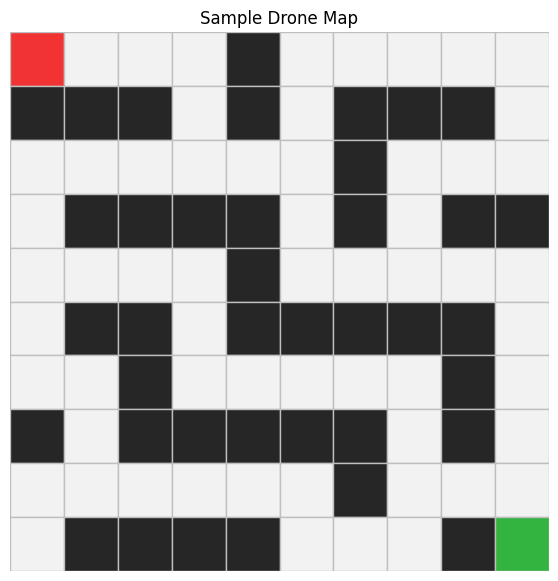

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
class SearchAlgorithm(ABC):
  """Base class for search algorithms."""

  def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
    # TODO 5:
    # Implement the AIMA-style EXPAND(problem, node).
    #
    # Pseudocode:
    # s <- node.STATE
    # for each action in problem.ACTIONS(s):
    #     s_prime <- problem.RESULT(s, action)
    #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
    #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

    s = node.state
    for action in problem.actions(s):
      s_prime = problem.result(s, action)
      cost = node.path_cost + problem.action_cost(s, action, s_prime)
      yield Node(state = s_prime, parent = node, action = action, path_cost = cost)
      

  @abstractmethod
  def search(self, problem: Problem) -> SearchResult:
    pass

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 1
        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if (problem.is_goal(node.state)):
            return SearchResult(algorithm = algorithm, status = "success", solution = node, nodes_expanded = nodes_expanded, max_frontier_size=max_frontier_size, reached_count=1)
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}

        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.***
        #       c. expand the node.***
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        while (frontier):
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if (problem.is_goal(s)):
                    return SearchResult(algorithm = algorithm, status = 'success', solution = child, nodes_expanded = nodes_expanded, max_frontier_size=max_frontier_size)
                
                if (s not in reached):
                    reached.add(s)
                    frontier.append(child)

            if len(frontier) > max_frontier_size:     
                max_frontier_size = len(frontier)
                
        # 6. Return failure if no solution is found.
        return SearchResult(algorithm = algorithm, status = 'failure', solution = None, nodes_expanded = nodes_expanded, max_frontier_size = max_frontier_size)
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 1

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm = algorithm,
                status='success',
                solution = node,
                nodes_expanded = nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count= 1
            )
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        # 4. Use a reached set.
        reached={problem.initial_state()}
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.**
        #       c. expand the node.**
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.**
        #
        while frontier:
            node=frontier.pop()
            nodes_expanded += 1

            for child in reversed(list(self.expand(problem, node))):
            # for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(algorithm = algorithm, status = 'success', solution = child, nodes_expanded = nodes_expanded, max_frontier_size = max_frontier_size, reached_count = len(reached))
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            if len(frontier) > max_frontier_size:
              max_frontier_size = len(frontier)

        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        return SearchResult(algorithm = algorithm, status = 'failure', solution = None, nodes_expanded = nodes_expanded, max_frontier_size = max_frontier_size, reached_count=len(reached))
        raise NotImplementedError("Complete DepthFirstSearch.search")

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return (node, "success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif (node.depth >= limit):
            return (None, "cutoff")
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue
                
                # metrics["max_stack_size"] = max(
                #     metrics["max_stack_size"],
                #     current_stack_size + 1
                # )
                if metrics["max_stack_size"] < current_stack_size + 1:
                   metrics["max_stack_size"] = current_stack_size + 1
            
                result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size + 1)

                if status == 'success':
                    return (result, 'success')
                if status == 'cutoff':
                    cutoff_occurred = True

            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")

                
    # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        iteration_log = []
        nodes_expanded = 0
        max_stack_size = 0

        for limit in range(0, max_depth):
            dls = DepthLimitedSearch()

            result = dls.search(problem, limit = limit) 
            iteration_log.append((limit, result.status))
            nodes_expanded += result.nodes_expanded

            if max_stack_size < result.max_frontier_size:
                max_stack_size = result.max_frontier_size

            if result.status == 'success':
                return SearchResult(algorithm = algorithm, status = 'success', max_frontier_size=max_stack_size, nodes_expanded=nodes_expanded, limit=limit, solution=result.solution)
            
            if result.status == 'failure':
                return SearchResult(algorithm = algorithm, status = 'failure', max_frontier_size=max_stack_size, nodes_expanded=nodes_expanded, limit = limit, solution = None)
            
        return SearchResult(algorithm = algorithm, status = 'cutoff', max_frontier_size=max_stack_size, nodes_expanded=nodes_expanded, limit = limit, solution = None)
                
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=18),
    ids.search(problem, max_depth=19),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,50,5,0
1,DFS,success,NaN,26,26,37,4,39
2,DLS,success,18.0,18,18,55,19,0
3,IDS,success,18.0,18,18,356,19,0


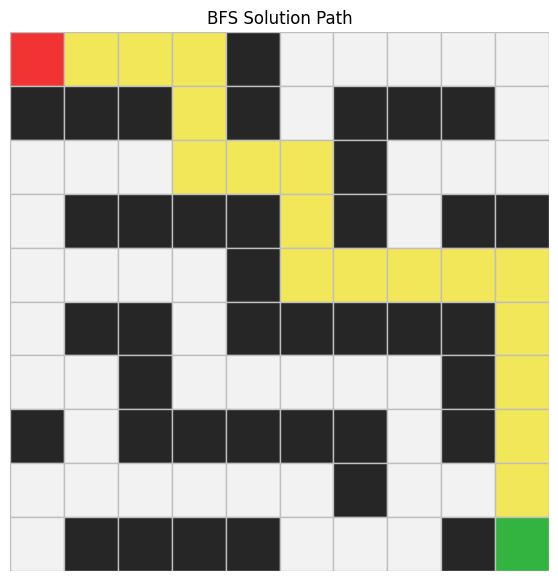

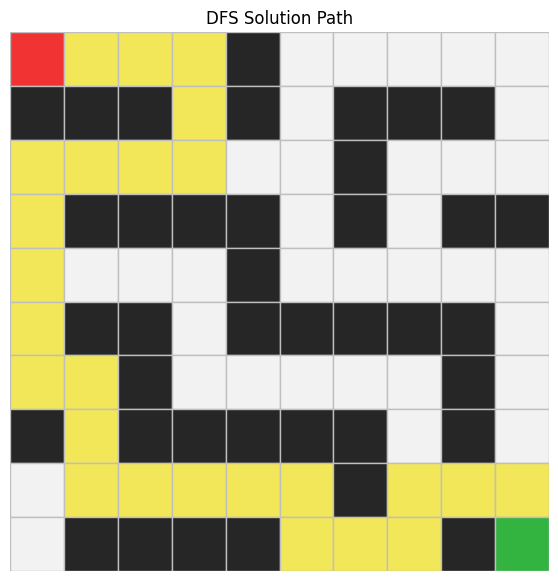

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [17]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
[0,0,1,0,0,0,1,0,0,0],
[1,0,1,0,1,0,1,0,1,0],
[0,0,0,0,1,0,0,0,1,0],
[0,1,1,1,1,1,1,0,1,0],
[0,0,0,0,0,0,1,0,1,0],
[1,1,1,1,1,0,1,0,1,0],
[0,0,0,0,1,0,0,0,1,0],
[0,1,1,0,1,1,1,0,1,0],
[0,0,1,0,0,0,1,0,0,0],
[1,0,0,0,1,0,0,0,1,0]
]

custom_start_1 = (0,0)
custom_goal_1 = (9,9)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,20,20,40,4,0
1,DFS,success,NaN,32,32,32,4,36
2,DLS,success,20.0,20,20,26,21,0
3,IDS,success,20.0,20,20,359,21,0


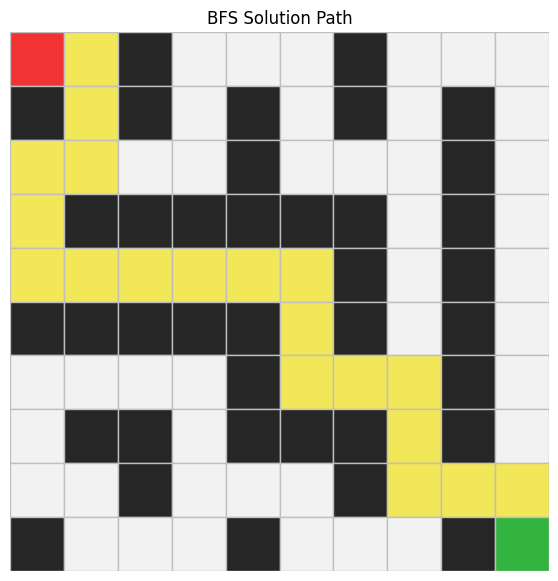

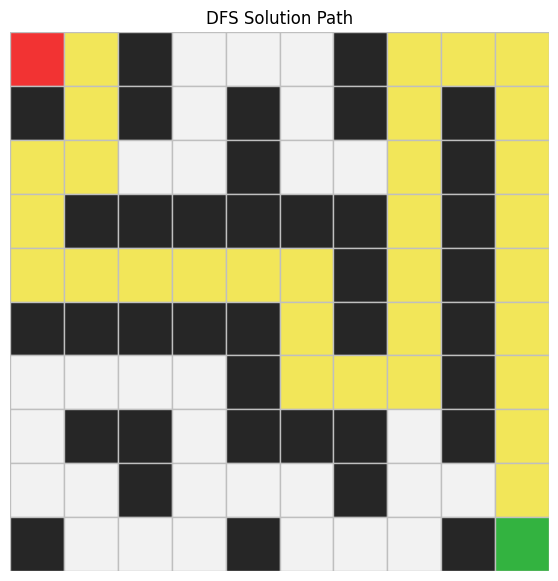

In [18]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="DFS Solution Path",
)

In [19]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
  [0,0,0,1,0,0,0,1,0,0],
  [1,1,0,1,0,1,0,1,0,1],
  [0,0,0,0,0,1,0,0,0,1],
  [0,1,1,1,0,1,1,1,0,0],
  [0,0,0,1,0,0,0,1,1,0],
  [1,1,0,1,1,1,0,0,0,0],
  [0,0,0,0,0,1,1,1,1,0],
  [0,1,1,1,0,0,0,0,1,0],
  [0,0,0,1,1,1,1,0,1,0],
  [1,1,0,0,0,0,0,0,0,0]
]

custom_start_2 = (0,0)
custom_goal_2 = (9,9)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,50,6,0
1,DFS,success,NaN,26,26,32,4,34
2,DLS,success,20.0,18,18,63,21,0
3,IDS,success,18.0,18,18,355,19,0


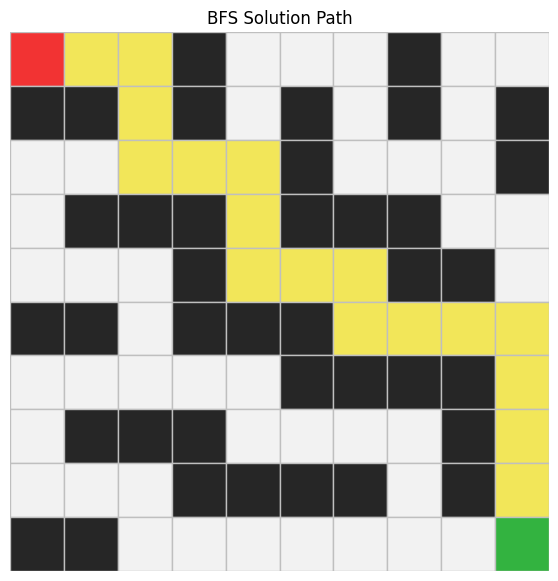

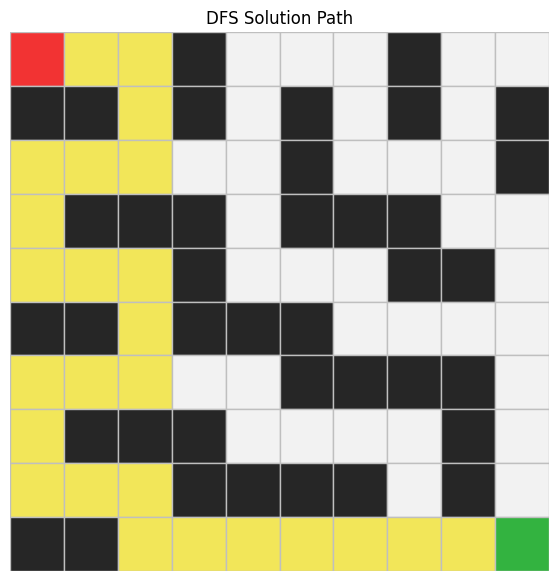

In [20]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="DFS Solution Path",
)

15.1 
1. A state describes the current location of a node on the grid.
2. An action is a movement from one state to another state.
3. The result function returns state when an action is taken.
4. 

15.2
1. BFS uses a FIFO queue because, it has to check at every node at each depth before moving to the next one. Thus when a queue is used at each depth, when nodes are produced, each node is explored first before their children are explored.
2. Because it checks per each depth of nodes before moving on to their children. This way you are able to go wide and check on all nodes before moving deeper. This way, there is a higher probability that you will find it if you are checking breadth wise.
3. The reached set tells the algorithm that it has already seen this node before, therefore there is no need to explore it again.

15.3 
1. DFS uses a stack because it has a first in, last out structure. This way, it is able to go explore deeper on one particular path before moving to the others.
2. DFS doesnt guarantee the shortest path because it goes down as deep through one branch. Even though it could find the goal at the deepest branch, there could be a chance that the goal was at a shorter depth in another branch.
3. DFS usually uses less memory when the trees are deep and wide as compared to BFS. This is because DFS has to just store the nodes along a particular path, whilst BFS has to store all the nodes at each depth.
4. DFS can perform badly when cycles are not being tracked, or when the goal is at the right most node(widest node).

12.4
1. If the depth limit is too small, there is a high chance of a cutoff because the goal could have been at a lower depth.
2. a cutoff is basically a result where the program couldnt successfully find the goal, and also wasnt allow to go any further down a depth.
3. DLS is "limited" in the sense that there is a given depth they are not allowed to pass. But for DFS no guardrails in terms of depth limit, so they can go as deep as possible.
4. We use path cycle checking in DLS to ensure that it doesnt work on a node that has already been reached. Thus it doesnt enter infinite loops

15.5
1. IDS repeats DLS with increasing limits because it is able to combine the memory efficiency of DFS, together with the high probability of attaining the goal with BFS. This is because all nodes at shallower limits are checked before going to nodes at deeper limits. Additionally the frontier is able to let go of unexplored nodes faster since the last node that enters will be the first to be explored.

2. IDS can be complete because the limit progressively increases, but for DLS, the limit is static and once the goal is not found within that limit it ends there.

3. IDS uses less memory than BFS because IDS only stores nodes on the path it is currently exploring as opposed to that of BFS where all nodes at each depth are stored.

4. The cost is that IDS goes through nodes it has already explored over and over again, because the whole structure is erased once the goal is not found at a particular limit.

15.6

1. In a real drone application, the terrain plays a huge factor. A calmer and less noisy terrain is safer as compared to one which has thunderstorms, winds, etc.

2. BFS will be chosen because it searches each depth before moving to the next. this way, it will find the goal with the fewest number of moves. With the rest, there is a chance that you might have to go deep before finding your desired goal.

3. I will choose DLS because it provides a depth limit with which the drone can know how deep to search.

4. With grids, it is assumed that an obstacle is stationary, but in the real world, obstacles can move from time to time. Also with the grid model, diagonal movement is limited, whereas the real world, the drone can easily move diagonally.